In [1]:
import numpy as np
from scipy import stats
import pandas as pd

import matplotlib.pyplot as plt

import sys
sys.path.append("../utils/")
import format_stim_data
import scipy.io
import os

In [2]:
''' set paths '''
save_folder = f"../figures/antidromic_hpc_to_lhy/"
data_folder = f"../data/antidromic_stim/"

if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save folder exists


In [3]:
''' get the bird and session info '''
# all bird names
bird_ids = os.listdir(data_folder)

# example bird
ex_id = 0
bird_id = bird_ids[ex_id]

# session IDs
sessions = os.listdir(f"{data_folder}{bird_id}")
ex_session = sessions[5]

In [30]:
''' load and format the data '''
voltage, timestamps = format_stim_data.load_stim(data_folder, bird_id, ex_session)

dt=0.0001
v, t = format_stim_data.resample(voltage, timestamps, dt=dt)

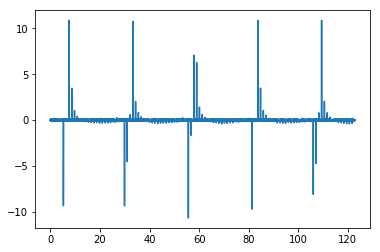

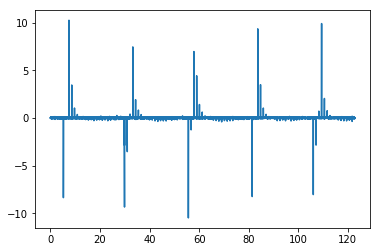

In [5]:
plt.plot(timestamps, voltage, 'k')
plt.show()

plt.plot(t, v, 'k')
plt.show()

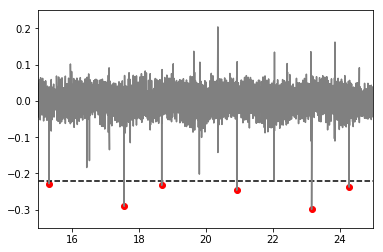

In [58]:
from scipy.signal import find_peaks

min_thresh=0.22
max_thresh=1

stim_idx, _ = find_peaks(-v, height=[min_thresh, max_thresh])

# sanity check
f, ax = plt.subplots(1, 1)
ax.plot(t, v, 'gray')
xlim = ax.get_xlim()

ax.hlines(-thresh, xlim[0], xlim[1], 
          colors='k', linestyles='dashed')
ax.scatter(t[stim_idx], v[stim_idx], c='r')

ax.set_xlim([15, 25])
ax.set_ylim([-0.35, 0.25])

plt.show()

In [59]:
''' plot each stimulation trial '''
before_t = 0.01 # 10ms
after_t = 0.03 # 30ms
b_idx = np.round(before_t / dt).astype(int)
a_idx = np.round(after_t / dt).astype(int)

n_bins = b_idx + a_idx
n_stim = stim_idx.shape[0]

stim_events = np.zeros((n_stim, n_bins))
for i, s_idx in enumerate(stim_idx):
    start = s_idx - b_idx
    end = s_idx + a_idx    
    stim_events[i] = v[start:end]

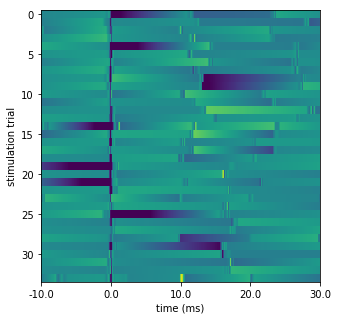

In [80]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(stim_events, clim=[-0.2, 0.2], 
          aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(0, 405, 100))
ax.set_xticklabels(np.arange(-10, 30.5, 10)) # ms

ax.set_ylabel('stimulation trial')
ax.set_xlabel('time (ms)')

plt.show()

In [28]:
np.diff(t[stim_idx])

array([2.249 , 1.1174, 1.1101, 1.1382, 4.4663, 2.243 , 1.1217, 2.2411,
       2.236 , 1.1226, 2.5101, 3.101 , 1.1169, 1.1179, 1.1181, 1.1166,
       1.1322, 1.1149, 4.4732, 1.126 , 1.1115, 1.1187, 1.122 , 1.1217,
       2.2379, 6.7324, 1.1167, 1.1183, 1.1167, 1.1177, 1.1222, 4.4807,
       1.1244, 1.1124, 1.1283, 1.1128, 1.1214, 1.1342, 1.1175, 7.8331,
       2.2386, 1.1164, 1.1327, 1.1175, 4.4838, 1.118 , 1.1027, 1.1319,
       2.235 , 1.132 , 1.1178, 6.7182, 1.1181, 1.1175, 1.1175, 1.1324,
       1.1179, 1.117 , 3.351 , 1.134 , 1.1173, 1.1165, 1.1177, 1.1172])